In [2]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from glob import glob as gg
from zipfile import ZipFile
from tensorflow.keras.models import load_model
# from google.colab.patches import cv2_imshow
from sklearn.model_selection import train_test_split

In [3]:
# symbol_path = "/content/drive/MyDrive/Datasets/pre_training.zip"

In [4]:
# assert os.path.exists(symbol_path)

In [ ]:
# with ZipFile(symbol_path, "r") as file:
#     # file.extractall(path = "/content/drive/MyDrive/Datasets/callbacks")
#     file.extractall(path = "/content/")
#     print("Done")
#     file.close()

Done


In [5]:
data = "pre_training"

dataset = tf.keras.utils.image_dataset_from_directory(
    data, image_size = (64, 64), batch_size = 64
)

Found 181730 files belonging to 53 classes.


In [6]:
data_itr = dataset.as_numpy_iterator()

In [7]:
batch = data_itr.next()

In [9]:
batch[0].shape

(64, 64, 64, 3)

In [12]:
# print(batch[1][3])
# cv2_imshow(batch[0][3])

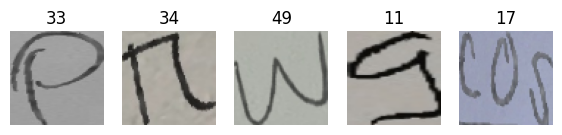

In [19]:
num = np.random.randint(0, 58)

fig, ax = plt.subplots(ncols = 5, figsize = (7, 7))
for idx, img in enumerate(batch[0][num:num + 5]):
    # ax[idx].imshow(img)
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][num])
    ax[idx].axis("off")
    num += 1

In [20]:
def image_processing(image, label):

    image = tf.cast(image / 255.0, tf.float32)

    return image, label

In [21]:
processed_data = dataset.map(image_processing)

processed_data = processed_data.shuffle(buffer_size = 1000, seed = 42)

In [22]:
train_size = int(len(processed_data) * 0.7)
test_size = int(len(processed_data) * 0.2)
val_size = int(len(processed_data) * 0.1) + 1

assert train_size + test_size + val_size == len(processed_data)

len(processed_data), train_size, test_size, val_size

(2840, 1987, 568, 285)

In [23]:
train = processed_data.take(train_size)
test = processed_data.skip(train_size).take(test_size)
val = processed_data.skip(train_size + test_size).take(val_size)

In [24]:
assert len(train) + len(test) + len(val) == len(processed_data)

In [25]:
train = train.prefetch(buffer_size = tf.data.AUTOTUNE)
test = test.prefetch(buffer_size = tf.data.AUTOTUNE)
val = val.prefetch(buffer_size = tf.data.AUTOTUNE)

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)

model = Sequential([
    Conv2D(
        filters = 32, kernel_size = (3, 3),
        activation = 'relu', input_shape = (64, 64, 3)
    ),
    BatchNormalization(),
    MaxPooling2D(pool_size = (3, 3)), # Imshape = 56, 56
    Conv2D(
        filters = 64, kernel_size = (2, 2),
        activation = 'relu'
    ),
    BatchNormalization(),
    MaxPooling2D(pool_size = (2, 2)),
    Conv2D(
        filters = 128, kernel_size = (2, 2),
        activation = 'relu'
    ),
    BatchNormalization(),
    MaxPooling2D(pool_size = (2, 2)),
    Conv2D(
        filters = 64, kernel_size = (2, 2),
        activation = 'relu'
    ),
    BatchNormalization(),
    MaxPooling2D(pool_size = (2, 2)),
    Flatten(),
    Dense(units = 32, activation = 'relu'),
    Dropout(rate = 0.3),
    Dense(units = 53, activation = 'softmax')
])

/Users/admin/Downloads/Code/SCHOOL_PROJECT/.env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import Accuracy
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping
)

best_weight_cb = ModelCheckpoint(
    filepath = 'models/symbol_model.keras',
    monitor = 'val_accuracy',
    verbose = 1,
    save_best_only = True
)

# early_stopping_cb = EarlyStopping(
#     monitor = 'val_loss',
#     patience = 3,
#     restore_best_weights = True
# )

# lr_scheduler = ExponentialDecay(
#     initial_learning_rate = 0.001,
#     decay_steps = 10000,
#     decay_rate = 0.96,
#     staircase = True
# )

model.compile(
    # optimizer = Adam(learning_rate = lr_scheduler),
    optimizer = Adam(learning_rate = 0.001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 19, 19, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 19, 19, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 3, 3, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 53)             │         1,749 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,861 (311.96 KB)

 Trainable params: 79,285 (309.71 KB)

 Non-trainable params: 576 (2.25 KB)

In [ ]:
model = model.fit(
    train,
    validation_data = val,
    batch_size = 64,
    epochs = 65,
    verbose = 1,
    callbacks = [best_weight_cb]
)

Epoch 1/65


2025-03-23 17:12:58.911563: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:9: Filling up shuffle buffer (this may take a while): 991 of 1000
2025-03-23 17:12:59.008403: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.


1987/1987 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.4717 - loss: 2.0207
Epoch 1: val_accuracy improved from -inf to 0.74391, saving model to models/symbol_model.keras
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 262s 127ms/step - accuracy: 0.4717 - loss: 2.0204 - val_accuracy: 0.7439 - val_loss: 0.8529
Epoch 2/65
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.7317 - loss: 0.9000
Epoch 2: val_accuracy improved from 0.74391 to 0.79742, saving model to models/symbol_model.keras
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 254s 123ms/step - accuracy: 0.7317 - loss: 0.9000 - val_accuracy: 0.7974 - val_loss: 0.6492
Epoch 3/65
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7695 - loss: 0.7538

2025-03-23 19:17:55.853036: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:9: Filling up shuffle buffer (this may take a while): 982 of 1000
2025-03-23 19:17:56.007144: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.



Epoch 3: val_accuracy did not improve from 0.79742
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 7014s 4s/step - accuracy: 0.7695 - loss: 0.7538 - val_accuracy: 0.6199 - val_loss: 1.6906
Epoch 4/65
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.7929 - loss: 0.6736
Epoch 4: val_accuracy did not improve from 0.79742
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 288s 140ms/step - accuracy: 0.7929 - loss: 0.6736 - val_accuracy: 0.7133 - val_loss: 0.9400
Epoch 5/65
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.8014 - loss: 0.6269
Epoch 5: val_accuracy improved from 0.79742 to 0.83031, saving model to models/symbol_model.keras
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 285s 138ms/step - accuracy: 0.8014 - loss: 0.6269 - val_accuracy: 0.8303 - val_loss: 0.5229
Epoch 6/65
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.8107 - loss: 0.6008
Epoch 6: val_accuracy did not improve from 0.83031
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 258s 125ms/step - accuracy: 0.8107 - loss: 0.6008 - val_accuracy: 0.7694 - val_l

...

   1/1987 ━━━━━━━━━━━━━━━━━━━━ 32:23:12 59s/step - accuracy: 0.8750 - loss: 0.4823

2025-03-24 02:11:09.001545: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.


1987/1987 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8831 - loss: 0.3432
Epoch 40: val_accuracy did not improve from 0.90329
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 15236s 8s/step - accuracy: 0.8831 - loss: 0.3432 - val_accuracy: 0.8786 - val_loss: 0.3774
Epoch 41/65
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8844 - loss: 0.3429
Epoch 41: val_accuracy improved from 0.90329 to 0.90680, saving model to models/symbol_model.keras
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 176s 86ms/step - accuracy: 0.8844 - loss: 0.3429 - val_accuracy: 0.9068 - val_loss: 0.2803
Epoch 42/65
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8839 - loss: 0.3481
Epoch 42: val_accuracy did not improve from 0.90680
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 177s 86ms/step - accuracy: 0.8839 - loss: 0.3481 - val_accuracy: 0.8913 - val_loss: 0.3443
Epoch 43/65
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8846 - loss: 0.3395
Epoch 43: val_accuracy did not improve from 0.90680
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 18

2025-03-24 07:58:11.774863: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:9: Filling up shuffle buffer (this may take a while): 842 of 1000
2025-03-24 07:58:14.517892: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.



Epoch 64: val_accuracy did not improve from 0.91960
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 277s 136ms/step - accuracy: 0.8942 - loss: 0.3049 - val_accuracy: 0.8200 - val_loss: 0.6983
Epoch 65/65
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.8942 - loss: 0.3038
Epoch 65: val_accuracy did not improve from 0.91960
1987/1987 ━━━━━━━━━━━━━━━━━━━━ 263s 128ms/step - accuracy: 0.8942 - loss: 0.3038 - val_accuracy: 0.8882 - val_loss: 0.3411


In [ ]:
history = model.history

In [43]:
train_accuracy = history["accuracy"]
val_accuracy = history["val_accuracy"]
train_loss = history["loss"]
val_loss = history["val_loss"]

In [89]:
from matplotlib import rcParams

dpi = 200 # 200-300 as per guidelines
maxpix = 670  # max pixels of plot
width = maxpix / dpi  # max allowed width
rcParams.update({'axes.labelsize': 'large', 'axes.titlesize': 'x-large',  # the size of labels and title
                 'xtick.labelsize': 'large', 'ytick.labelsize': 'large',  # the size of the axes ticks
                 'legend.fontsize': 'x-small', 'legend.frameon': False,  # legend font size, no frame
                 'legend.facecolor': 'none', 'legend.handletextpad': 0.25,
                 # legend no background colour, separation from label to point
                 'font.serif': ['Arial'],  # default fonts to try and use
                 'font.family': 'serif',  # use serif fonts
                 'mathtext.fontset': 'cm', 'mathtext.default': 'regular',  # if in math mode, use these
                 'figure.figsize': [0.4 * width,  (0.3 * width)], 'figure.dpi': dpi,
                 
                'text.color' : "black", 'axes.labelcolor' : "black",'axes.facecolor': 'white',
                 'xtick.color':'black', 'ytick.color':'black', 'figure.facecolor':'none',
                 
                 # the figure size in inches and dots per inch
                 'lines.linewidth': .75,  # width of plotted lines
                 'xtick.top': True, 'ytick.right': True,  # ticks on right and top of plot
                 'xtick.minor.visible': True, 'ytick.minor.visible': True,  # show minor ticks
                 'text.usetex': False, 'xtick.labelsize':'large',
                 'ytick.labelsize':'large'})

Path exists!


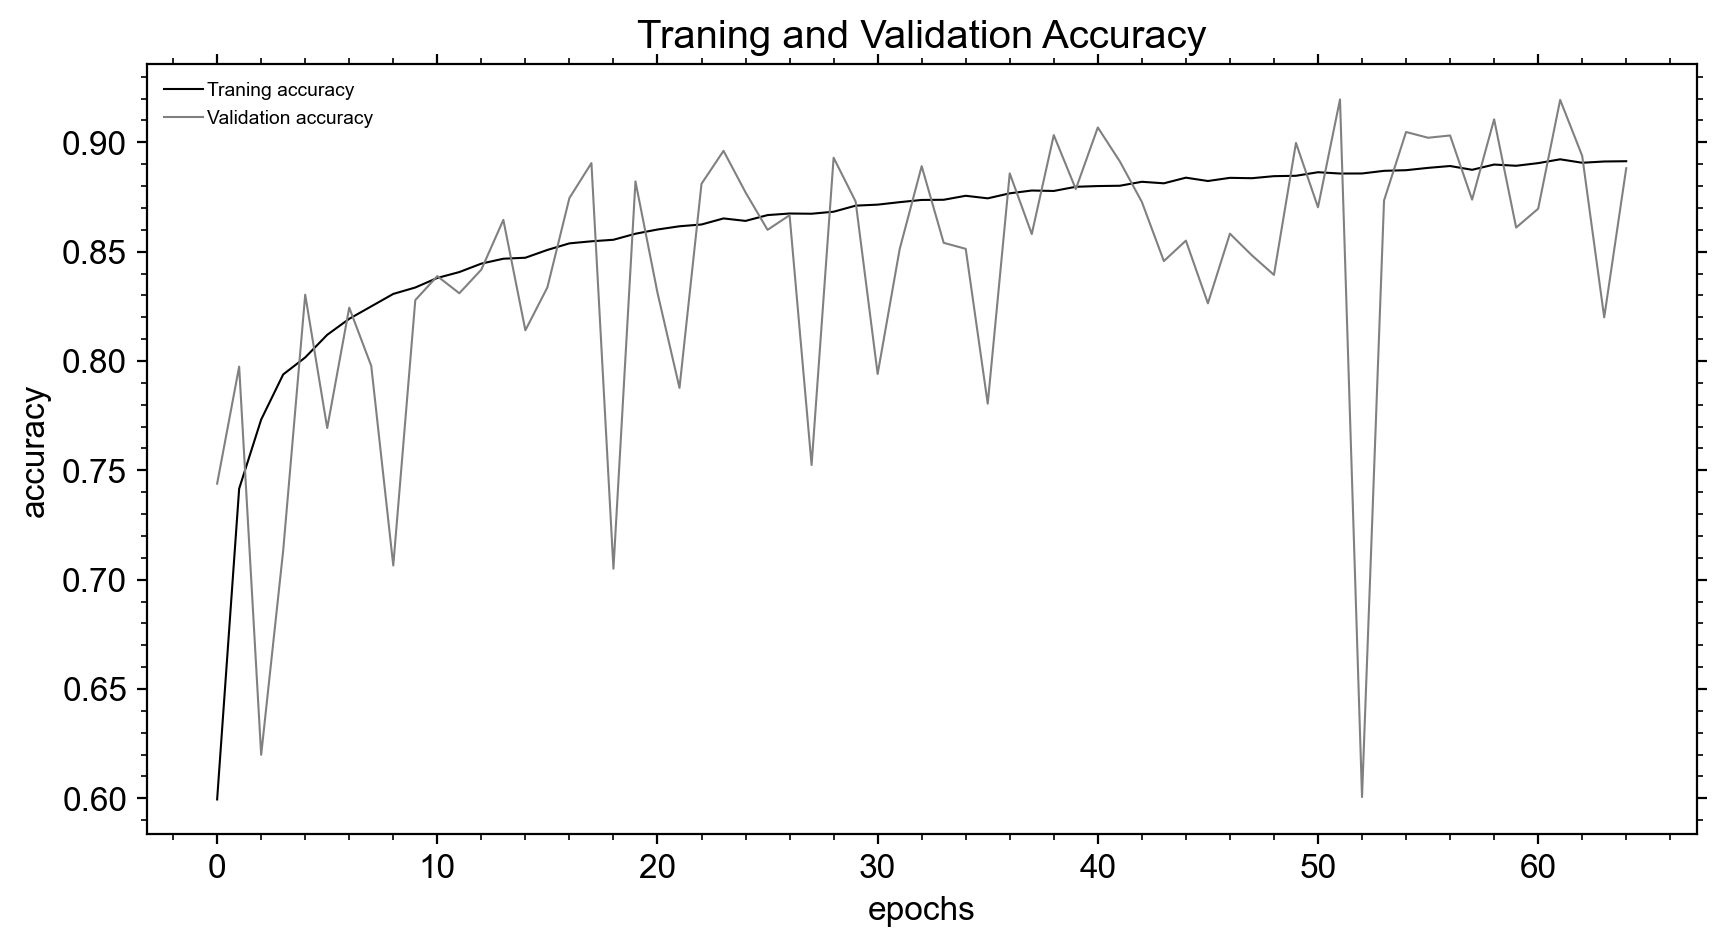

In [90]:
plt.figure(figsize = (10, 5))
plt.plot(train_accuracy, label = "Traning accuracy", color = 'k')
plt.plot(val_accuracy, label = "Validation accuracy", color = "grey")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title("Traning and Validation Accuracy")
plt.legend()
path = "charts/"
print("Path exists!") if os.path.exists(path) else os.mkdir(path)
count = len(gg(f"{path}/accuracy*.png"))
# plt.savefig(os.path.join(path, f"accuracy_{count}.png"))
plt.show()

Path exists!


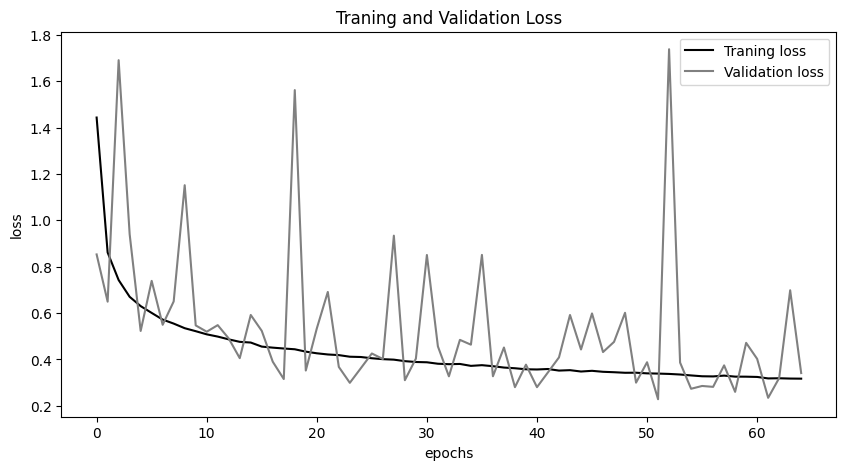

In [ ]:
plt.figure(figsize = (10, 5))
plt.plot(train_loss, label = "Traning loss", color = 'k')
plt.plot(val_loss, label = "Validation loss", color = "grey")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("Traning and Validation Loss")
plt.legend()
path = "charts/"
print("Path exists!") if os.path.exists(path) else os.mkdir(path)
count = len(gg(f"{path}/loss*.png"))
# plt.savefig(os.path.join(path, f"loss_{count}.png"))
plt.show()

In [3]:
model = load_model("models/symbol_model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted classes: [50 11 29 46 24]


TypeError: Invalid shape (0, 64, 64, 3) for image data

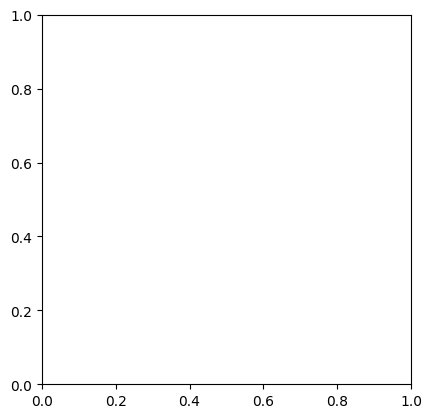

In [ ]:
# Assuming you have some input data for prediction
sample_data = batch[0][:5]  # Using a few images from the batch as an example

predictions = model.predict(sample_data)
predicted_classes = np.argmax(predictions, axis=1)

print("Predicted classes:", predicted_classes)

fig, ax = plt.subplots(ncols = 5, figsize = (7, 7))
for idx, img in enumerate(batch[0][:5]):
    # ax[idx].imshow(img)
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][num])
    ax[idx].axis("off")
    num += 1

In [ ]:
# # GPU Acceleration - Random order
# training_set = training_set.batch(batch_size = 32)
# training_set = training_set.prefetch(buffer_size = tf.data.AUTOTUNE)
# training_set = training_set.cache()
# training_set = training_set.shuffle(buffer_size = 1000, seed = 42)

# # Right Order
# training_set = training_set.cache()
# training_set = training_set.shuffle(buffer_size=1000, seed=42)
# training_set = training_set.batch(batch_size=32)
# training_set = training_set.prefetch(buffer_size=tf.data.AUTOTUNE)